# Metropolis, Gibbs, and Ising: exact kernels can still mix badly

Metropolis--Hastings corrects a proposal with an accept/reject step. Gibbs sampling replaces a
block by an exact conditional draw. Both can preserve a target exactly, but their finite-run
usefulness depends on proposal scale, scan order, geometry, and metastability.

This notebook uses the public `sampler_lab.mcmc`, `sampler_lab.models`, and
`sampler_lab.diagnostics` namespaces.

**Output semantics:** exact-invariant Markov kernels after all tuning is fixed. The retained
trajectory includes rejected repeats; deleting them changes the law.

Related pages: [Gibbs and Metropolis--Hastings](../methods/gibbs_metropolis.md),
[finite-state Markov theory](04_finite_state_markov_theory.ipynb), and
[public API](../api.md).


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import OperationCounter, spawn_rngs
from sampler_lab.diagnostics import empirical_integrated_autocorrelation_time
from sampler_lab.mcmc import (
    GaussianRandomWalkProposal,
    MetropolisHastingsKernel,
    run_chain,
)
from sampler_lab.models import (
    GaussianTarget,
    IsingModel,
    RandomScanIsingMetropolisKernel,
    deterministic_sweep_ising_gibbs,
    exact_ising_distribution,
    random_scan_ising_gibbs,
)

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Minimal Metropolis--Hastings example

For proposal density $q(y\mid x)$, Metropolis--Hastings accepts with

$$
\alpha(x,y)=1\wedge
\frac{\pi(y)q(x\mid y)}{\pi(x)q(y\mid x)}.
$$

The package evaluates all four log-density terms even for symmetric proposals. This keeps the
correction visible and prevents a state-dependent proposal from accidentally being treated as
symmetric.


In [2]:
target_covariance = np.array([[1.0, 0.92], [0.92, 1.0]])
target = GaussianTarget([0.0, 0.0], target_covariance)
counter = OperationCounter()
kernel = MetropolisHastingsKernel(
    target,
    GaussianRandomWalkProposal(0.55),
    counter=counter,
)
trajectory = run_chain(
    kernel,
    np.array([3.0, -3.0]),
    np.random.default_rng(SEED + 200),
    n_steps=3500 if QUICK_MODE else 18000,
)
retained = trajectory.samples(discard=700 if QUICK_MODE else 3000)

print("acceptance rate:", round(float(trajectory.acceptance_rate), 4))
print("rejections retained:", trajectory.n_rejections)
print("empirical mean:", np.round(retained.mean(axis=0), 4))
print("empirical covariance:\n", np.round(np.cov(retained.T), 3))
print("log-density evaluations:", counter.log_density_evaluations)

assert trajectory.n_rejections > 0
assert trajectory.states.shape[0] == trajectory.n_steps + 1

acceptance rate: 0.489
rejections retained: 9198
empirical mean: [0.0506 0.045 ]
empirical covariance:
 [[0.951 0.877]
 [0.877 0.965]]
log-density evaluations: 36000


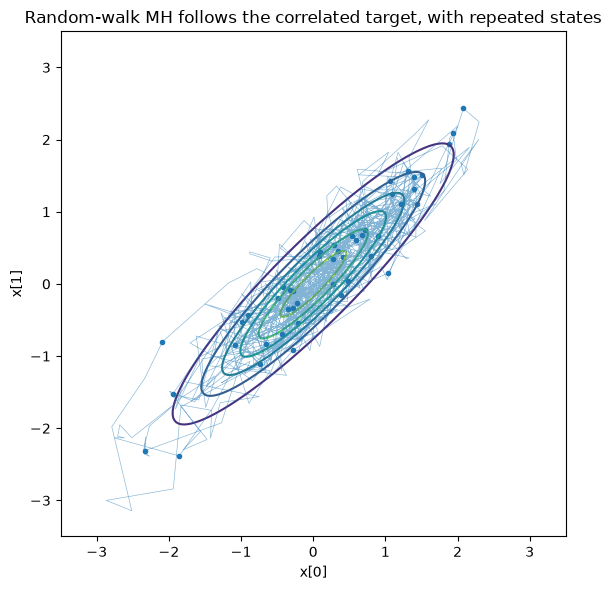

In [3]:
grid = np.linspace(-3.5, 3.5, 180)
xx, yy = np.meshgrid(grid, grid)
points = np.stack([xx, yy], axis=-1)
precision = np.linalg.inv(target_covariance)
quadratic = np.einsum("...i,ij,...j->...", points, precision, points)

fig, ax = plt.subplots(figsize=(6.5, 6.0))
ax.contour(xx, yy, np.exp(-0.5 * quadratic), levels=8)
shown = retained[: min(1600, retained.shape[0])]
ax.plot(shown[:, 0], shown[:, 1], linewidth=0.45, alpha=0.55)
ax.scatter(shown[::35, 0], shown[::35, 1], s=9)
ax.set_aspect("equal")
ax.set_xlabel("x[0]")
ax.set_ylabel("x[1]")
ax.set_title("Random-walk MH follows the correlated target, with repeated states")
finish_figure(fig)

## 2. Proposal-scale study

A tiny random walk accepts almost everything but moves slowly. An enormous random walk
proposes far into the tails and rejects almost everything. A useful scale balances movement
and acceptance; acceptance rate alone is not the objective.

We compare scale, acceptance, integrated autocorrelation time, and expected squared jump
distance (ESJD) using independent fixed-seed trajectories.


In [4]:
scales = np.array([0.08, 0.20, 0.45, 0.90, 1.8, 3.5])
scale_rngs = spawn_rngs(SEED + 210, scales.size)
scale_steps = 4500 if QUICK_MODE else 22000
burn_in = 800 if QUICK_MODE else 3500
scale_rows = []
scale_trajectories = {}

for scale, rng in zip(scales, scale_rngs, strict=True):
    proposal = GaussianRandomWalkProposal(float(scale))
    chain = run_chain(
        MetropolisHastingsKernel(target, proposal),
        np.zeros(2),
        rng,
        n_steps=scale_steps,
    )
    samples = chain.samples(discard=burn_in)
    x0 = samples[:, 0]
    iat = empirical_integrated_autocorrelation_time(x0)
    jumps = np.diff(chain.states[burn_in:], axis=0)
    esjd = float(np.mean(np.sum(jumps * jumps, axis=1)))
    scale_rows.append((scale, chain.acceptance_rate, iat, esjd))
    scale_trajectories[float(scale)] = chain
    print(
        f"scale={scale:4.2f} acceptance={chain.acceptance_rate:.3f} IAT={iat:7.2f} ESJD={esjd:.4f}"
    )

scale_rows = np.asarray(scale_rows, dtype=np.float64)

scale=0.08 acceptance=0.908 IAT= 794.32 ESJD=0.0112


scale=0.20 acceptance=0.771 IAT= 174.96 ESJD=0.0536


scale=0.45 acceptance=0.546 IAT=  59.71 ESJD=0.1561


scale=0.90 acceptance=0.315 IAT=  47.13 ESJD=0.2512


scale=1.80 acceptance=0.147 IAT=  26.28 ESJD=0.3194


scale=3.50 acceptance=0.057 IAT=  33.31 ESJD=0.2286


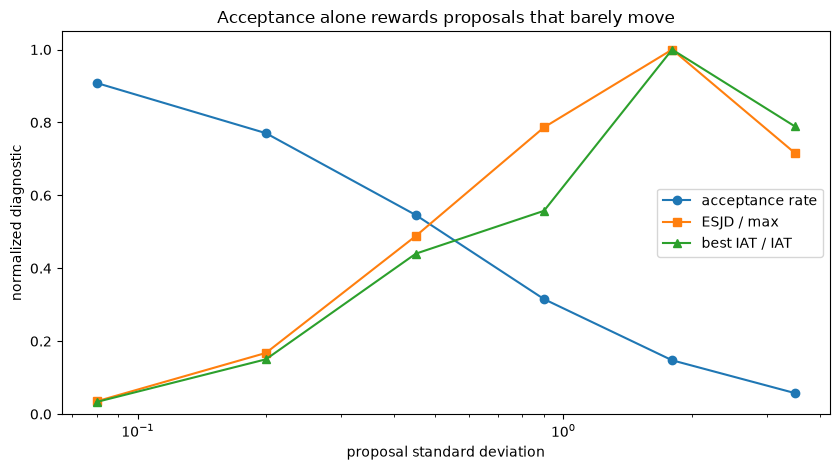

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(scale_rows[:, 0], scale_rows[:, 1], "o-", label="acceptance rate")
ax.plot(scale_rows[:, 0], scale_rows[:, 3] / np.max(scale_rows[:, 3]), "s-", label="ESJD / max")
ax.plot(
    scale_rows[:, 0],
    np.min(scale_rows[:, 2]) / scale_rows[:, 2],
    "^-",
    label="best IAT / IAT",
)
ax.set_xscale("log")
ax.set_xlabel("proposal standard deviation")
ax.set_ylabel("normalized diagnostic")
ax.set_ylim(0.0, 1.05)
ax.set_title("Acceptance alone rewards proposals that barely move")
ax.legend()
finish_figure(fig)

## Controlled failure: deleting rejections creates the jump chain

A rejection is a real transition $X_{k+1}=X_k$. If repeated states are deleted, the remaining
jump chain is generally not distributed according to the original target. We compare the
variance of the retained MH chain with the variance of accepted destinations only for a
deliberately oversized proposal.


oversized-proposal acceptance: 0.05736363636363637
variance with rejection repeats: 1.084
variance after deleting repeats: 1.2986


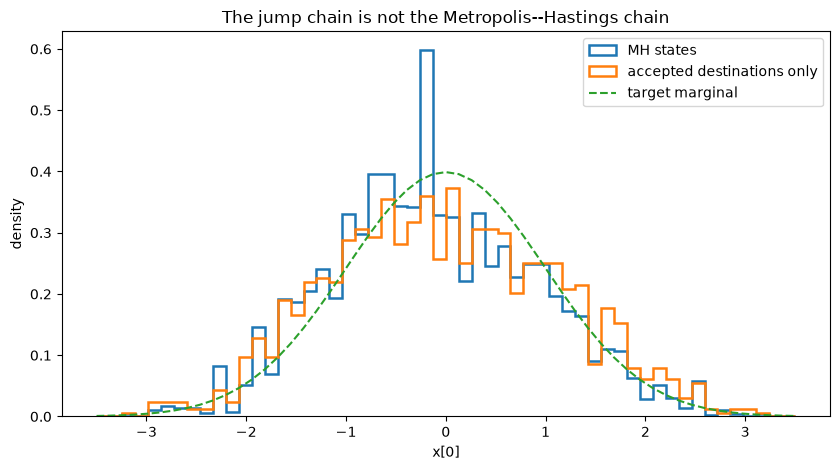

In [6]:
bad_chain = scale_trajectories[3.5]
bad_states = bad_chain.states[burn_in:]
accepted_destinations = bad_chain.states[1:][bad_chain.accepted]
full_variance = np.var(bad_states[:, 0])
jump_variance = np.var(accepted_destinations[:, 0])
print("oversized-proposal acceptance:", bad_chain.acceptance_rate)
print("variance with rejection repeats:", round(float(full_variance), 4))
print("variance after deleting repeats:", round(float(jump_variance), 4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bins = np.linspace(-3.5, 3.5, 55)
ax.hist(
    bad_states[:, 0], bins=bins, density=True, histtype="step", linewidth=1.8, label="MH states"
)
ax.hist(
    accepted_destinations[:, 0],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="accepted destinations only",
)
normal = np.exp(-0.5 * bins * bins) / np.sqrt(2.0 * np.pi)
ax.plot(bins, normal, linestyle="--", label="target marginal")
ax.set_xlabel("x[0]")
ax.set_ylabel("density")
ax.set_title("The jump chain is not the Metropolis--Hastings chain")
ax.legend()
finish_figure(fig)

## 3. Gibbs and Metropolis on a periodic Ising model

For spins $s_i\in\{-1,+1\}$,

$$
\pi(s)\propto \exp\left[\beta\left(J\sum_{\langle i,j\rangle}s_is_j
+h\sum_i s_i\right)\right].
$$

A single-site Gibbs update samples the exact conditional spin law. A single-spin Metropolis
update proposes a flip and uses its local energy change. Random scan and deterministic sweep
both preserve the target, but the sweep is a composition kernel and is generally not
reversible.

We first use a $2\times2$ lattice, where exact enumeration gives a reference distribution for
absolute magnetization.


In [7]:
def run_ising_series(model, method, rng, sweeps, burn):
    if method == "random-scan Gibbs":
        kernel = random_scan_ising_gibbs(model)
        updates_per_sweep = model.n_sites
    elif method == "deterministic-sweep Gibbs":
        kernel = deterministic_sweep_ising_gibbs(model)
        updates_per_sweep = 1
    elif method == "single-spin Metropolis":
        kernel = RandomScanIsingMetropolisKernel(model)
        updates_per_sweep = model.n_sites
    else:
        raise ValueError(method)

    state = model.random_state(rng)
    magnetization = np.empty(sweeps)
    energy = np.empty(sweeps)
    accepted = 0
    observed = 0
    for sweep in range(burn + sweeps):
        for _ in range(updates_per_sweep):
            transition = kernel.step(state, rng)
            state = np.asarray(transition.state, dtype=np.float64)
            if transition.accepted is not None:
                observed += 1
                accepted += int(transition.accepted)
        if sweep >= burn:
            index = sweep - burn
            magnetization[index] = model.magnetization(state, normalized=True)
            energy[index] = model.energy(state) / model.n_sites
    acceptance = None if observed == 0 else accepted / observed
    return magnetization, energy, acceptance


small_model = IsingModel(2, 0.62)
exact_small = exact_ising_distribution(small_model)
methods = ("random-scan Gibbs", "deterministic-sweep Gibbs", "single-spin Metropolis")
ising_rngs = spawn_rngs(SEED + 220, len(methods))
small_runs = {}
small_sweeps = 5000 if QUICK_MODE else 35000
small_burn = 800 if QUICK_MODE else 4000

for method, rng in zip(methods, ising_rngs, strict=True):
    magnetization, energy, acceptance = run_ising_series(
        small_model, method, rng, small_sweeps, small_burn
    )
    small_runs[method] = (magnetization, energy, acceptance)
    print(
        f"{method:>27}: E|m|={np.mean(np.abs(magnetization)):.4f}, "
        f"IAT={empirical_integrated_autocorrelation_time(np.abs(magnetization)):.2f}, "
        f"acceptance={acceptance}"
    )

          random-scan Gibbs: E|m|=0.9724, IAT=3.21, acceptance=None


  deterministic-sweep Gibbs: E|m|=0.9728, IAT=1.91, acceptance=None


     single-spin Metropolis: E|m|=0.9703, IAT=3.27, acceptance=0.042673076923076925


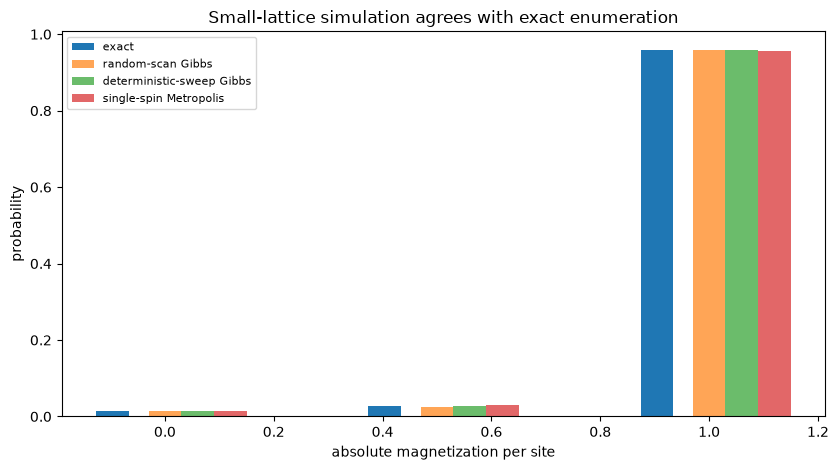

In [8]:
exact_abs_values = np.abs(exact_small.magnetizations) / small_model.n_sites
support = np.unique(exact_abs_values)
exact_probabilities = np.array(
    [np.sum(exact_small.probabilities[exact_abs_values == value]) for value in support]
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
width = 0.06
offsets = np.linspace(-width, width, len(methods))
ax.bar(support - 1.6 * width, exact_probabilities, width=width, label="exact")
total_variation_errors = []
for offset, method in zip(offsets, methods, strict=True):
    observed = np.abs(small_runs[method][0])
    empirical = np.array([np.mean(np.isclose(observed, value)) for value in support])
    total_variation_errors.append(0.5 * np.sum(np.abs(empirical - exact_probabilities)))
    ax.bar(support + offset + width, empirical, width=width, alpha=0.7, label=method)
ax.set_xlabel("absolute magnetization per site")
ax.set_ylabel("probability")
ax.set_title("Small-lattice simulation agrees with exact enumeration")
ax.legend(fontsize=8)
finish_figure(fig)

## 4. Low-temperature mode trapping

At larger $\beta$, positive- and negative-magnetization phases are separated by a low-density
region. A local exact-invariant kernel can remain in one phase for a very long time. The trace
below uses a modest lattice and deliberately short runs: it is a diagnostic of metastability,
not evidence that one phase is the whole target.


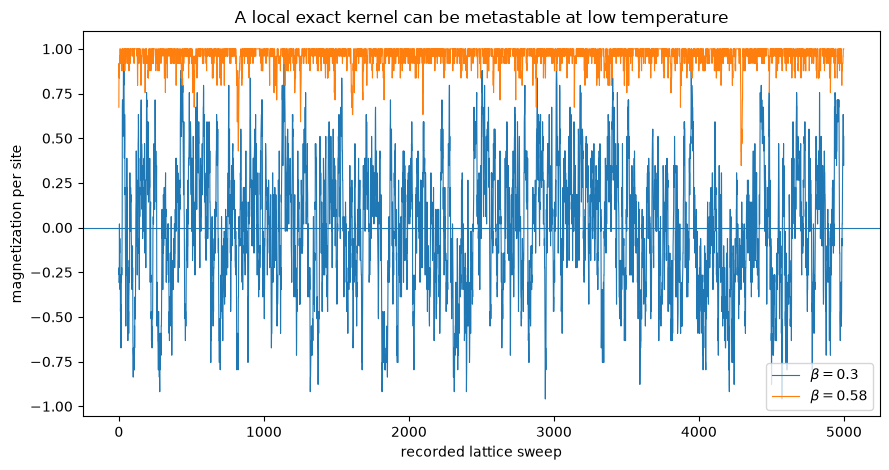

In [9]:
lattice_size = 5 if QUICK_MODE else 7
trace_sweeps = 1200 if QUICK_MODE else 5000
trace_burn = 250 if QUICK_MODE else 800
temperatures = [0.30, 0.58]
trace_rngs = spawn_rngs(SEED + 230, len(temperatures))
trace_runs = {}

for beta, rng in zip(temperatures, trace_rngs, strict=True):
    model = IsingModel(lattice_size, beta)
    magnetization, _, _ = run_ising_series(
        model, "random-scan Gibbs", rng, trace_sweeps, trace_burn
    )
    trace_runs[beta] = magnetization

fig, ax = plt.subplots(figsize=(9.0, 4.8))
for beta, values in trace_runs.items():
    ax.plot(values, linewidth=0.8, label=rf"$\beta={beta}$")
ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel("recorded lattice sweep")
ax.set_ylabel("magnetization per site")
ax.set_title("A local exact kernel can be metastable at low temperature")
ax.legend()
finish_figure(fig)

## When to use these kernels

Metropolis--Hastings is a general correction mechanism when a proposal can be sampled and
evaluated in both directions. Gibbs sampling is attractive when exact conditional draws are
available. Both require diagnostics tied to the estimand and computational cost. Proposal
tuning must finish before an exact-invariant evaluation run is interpreted.

Further experiments:

- replace the diagonal random walk by a covariance-matched proposal;
- compare random-scan and deterministic-sweep exact transition matrices on the $2\times2$
  Ising model;
- increase lattice size near criticality and watch finite-run IAT estimates become unstable.


In [10]:
covariance_error = np.max(np.abs(np.cov(retained.T) - target_covariance))
low_temperature_sign_changes = np.count_nonzero(
    np.sign(trace_runs[0.58][1:]) != np.sign(trace_runs[0.58][:-1])
)
print("largest covariance entry error:", round(float(covariance_error), 4))
print("low-temperature sign changes:", low_temperature_sign_changes)
print("small-lattice TV errors:", np.round(total_variation_errors, 4))

assert 0.05 < trajectory.acceptance_rate < 0.95
assert covariance_error < (0.35 if QUICK_MODE else 0.18)
assert max(total_variation_errors) < (0.16 if QUICK_MODE else 0.07)
assert FIGURE_COUNT >= 5
print(f"completed MCMC and Ising notebook with {FIGURE_COUNT} figures")

largest covariance entry error: 0.0491
low-temperature sign changes: 0
small-lattice TV errors: [0.0011 0.0009 0.0039]
completed MCMC and Ising notebook with 5 figures
